# EXPLICACIÓN SOBRE DATASET

In [ ]:
import os
import pickle
from funciones_aasist import *
device = "cpu"

from AASIST import Model

model = torch.load("aasist_full.pt", map_location=device, weights_only=False)
model.eval()

bonas = ["Español/E_10_N.wav","Español/E_20_N.wav","Español/E_30_N.wav","Español/E_40_N.wav", "Español/E_50_N.wav","Inglés/I_10_N.wav","Inglés/I_20_N.wav","Inglés/I_30_N.wav","Inglés/I_40_N.wav","Inglés/I_50_N.wav"]
spoofs = ["Español/E_10_G.wav","Español/E_20_G.wav","Español/E_30_G.wav","Español/E_40_G.wav","Español/E_50_G.wav","Inglés/I_10_G.wav","Inglés/I_20_G.wav","Inglés/I_30_G.wav","Inglés/I_40_G.wav","Inglés/I_50_G.wav"]
base_pathN = r"C:\TFG\Datasets\Propio\Natural"
base_pathG = r"C:\TFG\Datasets\Propio\Generado"
bonas = {os.path.join(base_pathN, f) for f in bonas}
spoofs = {os.path.join(base_pathG, f) for f in spoofs}

In [ ]:
with open("igsc_maps.pkl", "rb") as f:
    resultados_aasist = pickle.load(f)

resultados_aasist["bonas"] = bonas
resultados_aasist["spoofs"] = spoofs

In [ ]:
def scan_to_vector(scan_dict, key="inc_margin"):
    return np.array([r[key] for r in scan_dict["results"]], dtype=np.float32)

In [ ]:
maps_bonasOccMargin = []
maps_spoofsOccLogit = []
maps_bonasOccLogit = []
maps_spoofsOccMargin = []

occ_ms = 50
hop_ms = 10
fill_mode = "zero"

for b in bonas:
    bx, bx4, t = normalize_audio(b)
    x = bx4.copy()
    long_audio = len(x)

    scan = hiding_scan(t, x, long_audio, model = model, occ_ms=occ_ms, hop_ms=hop_ms, fill_mode=fill_mode)

    occ_margin = scan_to_vector(scan, key="inc_margin")
    occ_logit = scan_to_vector(scan, key="inc_logit")

    maps_bonasOccMargin.append(occ_margin)
    maps_bonasOccLogit.append(occ_logit)

    print(f"Bonas {b}")

for s in spoofs:
    bx, bx4, t = normalize_audio(s)
    x = bx4.copy()
    long_audio = len(x)

    scan = hiding_scan(t, x, long_audio, model = model, occ_ms=occ_ms, hop_ms=hop_ms, fill_mode=fill_mode)

    occ_margin = scan_to_vector(scan, key="inc_margin")
    occ_logit = scan_to_vector(scan, key="inc_logit")

    maps_spoofsOccMargin.append(occ_margin)
    maps_spoofsOccLogit.append(occ_logit)

    print(f"Spoofs {s}")

Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_10_N.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_30_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_20_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_20_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_10_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_30_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Espa

In [ ]:
resultados_aasist["maps_bonasOccMargin"] = maps_bonasOccMargin
resultados_aasist["maps_spoofsOccMargin"] = maps_spoofsOccMargin
resultados_aasist["maps_bonasOccLogit"] = maps_bonasOccLogit
resultados_aasist["maps_spoofsOccLogit"] = maps_spoofsOccLogit

with open("igsc_maps.pkl", "wb") as f:
    pickle.dump(resultados_aasist, f)

In [ ]:
maps_bonasOccMargin = resultados_aasist["maps_bonasOccMargin"]
maps_spoofsOccMargin = resultados_aasist["maps_spoofsOccMargin"]
maps_bonasOccLogit = resultados_aasist["maps_bonasOccLogit"]
maps_spoofsOccLogit = resultados_aasist["maps_spoofsOccLogit"]

occ_ms = 50
hop_ms = 10

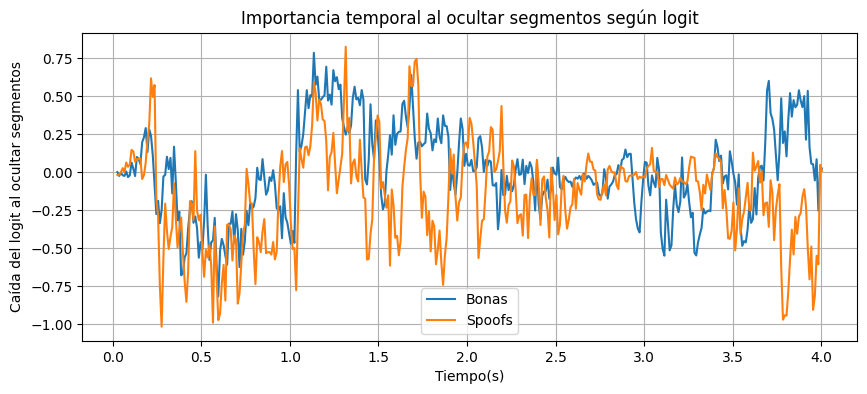

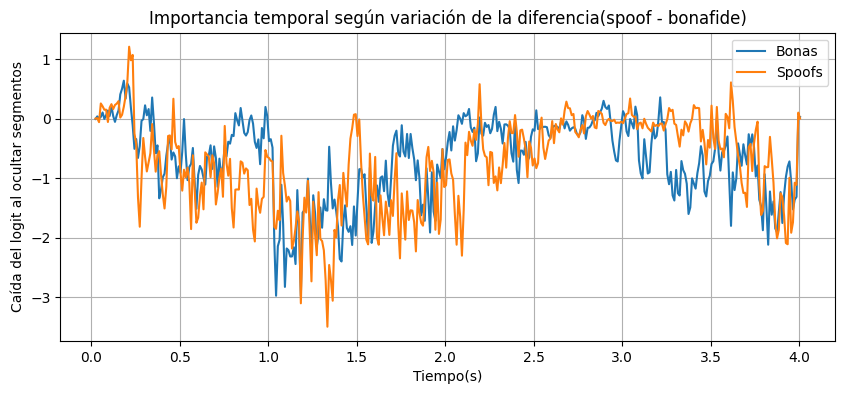

In [ ]:
maps_bonasOccMargin = np.stack(maps_bonasOccMargin, axis=0)
maps_spoofsOccMargin = np.stack(maps_spoofsOccMargin, axis=0)

maps_bonasOccLogit = np.stack(maps_bonasOccLogit, axis=0)
maps_spoofsOccLogit = np.stack(maps_spoofsOccLogit, axis=0)

OccMargin_mean_bonas = maps_bonasOccMargin.mean(axis=0)
OccMargin_mean_spoofs = maps_spoofsOccMargin.mean(axis=0)

OccLogit_mean_bonas = maps_bonasOccLogit.mean(axis=0)
OccLogit_mean_spoofs = maps_spoofsOccLogit.mean(axis=0)


x_sec = np.arange(len(OccMargin_mean_bonas)) * (hop_ms / 1000.0) + (occ_ms / 2000.0)

plt.figure(figsize=(10,4))
plt.plot(x_sec, OccLogit_mean_bonas, label="Bonas")
plt.plot(x_sec, OccLogit_mean_spoofs, label="Spoofs")
plt.xlabel("Tiempo")
plt.ylabel("Caída del logit al ocultar segmentos")
plt.title("Importancia temporal al ocultar segmentos según logit")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(x_sec, OccMargin_mean_bonas, label="Bonas")
plt.plot(x_sec, OccMargin_mean_spoofs, label="Spoofs")
plt.xlabel("Tiempo")
plt.ylabel("Caída del logit al ocultar segmentos")
plt.title("Importancia temporal según variación de la diferencia(spoof - bonafide)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
maps_bonasFreqMargin = []
maps_spoofsFreqMargin = []
maps_bonasFreqLogit = []
maps_spoofsFreqLogit = []

n_bands = 16
fmax = 8000

for b in bonas:
    bx, bx4, t = normalize_audio(b)

    # tu función usa long_audio dentro
    x = bx.copy()
    long_audio = len(x)

    out_freq = hiding_scan_freq(t=t, x=x, long_audio=long_audio, model = model, target_class=None, n_bands=n_bands, fmax=fmax)


    vec_margin = scan_to_vector(out_freq, key="inc_margin")
    vec_logit = scan_to_vector(out_freq, key="inc_logit")

    maps_bonasFreqMargin.append(vec_margin)
    maps_bonasFreqLogit.append(vec_logit)

    print(f"Bonas {b}")

for s in spoofs:
    bx, bx4, t = normalize_audio(s)

    # tu función usa long_audio dentro
    x = bx.copy()
    long_audio = len(x)

    out_freq = hiding_scan_freq(t=t, x=x, model = model, long_audio=long_audio, target_class=None, n_bands=n_bands, fmax=fmax)


    vec_margin = scan_to_vector(out_freq, key="inc_margin")
    vec_logit = scan_to_vector(out_freq, key="inc_logit")

    maps_spoofsFreqMargin.append(vec_margin)
    maps_spoofsFreqLogit.append(vec_logit)

    print(f"Spoofs {s}")

Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_40_N.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_30_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_30_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_10_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_40_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_40_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Ing

In [ ]:
resultados_aasist["maps_bonasFreqMargin"] = maps_bonasFreqMargin
resultados_aasist["maps_spoofsFreqMargin"] = maps_spoofsFreqMargin
resultados_aasist["maps_bonasFreqLogit"] = maps_bonasFreqLogit
resultados_aasist["maps_spoofsFreqLogit"] = maps_spoofsFreqLogit

with open("igsc_maps.pkl", "wb") as f:
    pickle.dump(resultados_aasist, f)

In [ ]:
maps_bonasFreqMargin = resultados_aasist["maps_bonasFreqMargin"]
maps_spoofsFreqMargin = resultados_aasist["maps_spoofsFreqMargin"]
maps_bonasFreqLogit = resultados_aasist["maps_bonasFreqLogit"]
maps_spoofsFreqLogit = resultados_aasist["maps_spoofsFreqLogit"]

n_bands = 16
fmax = 8000

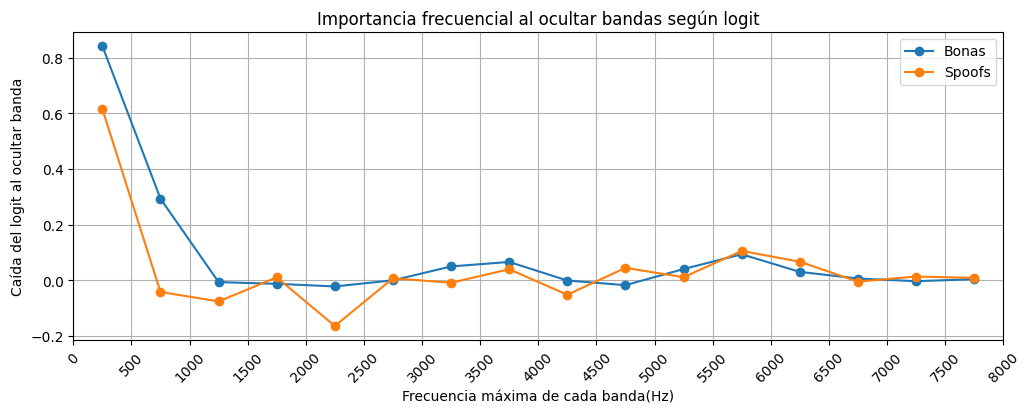

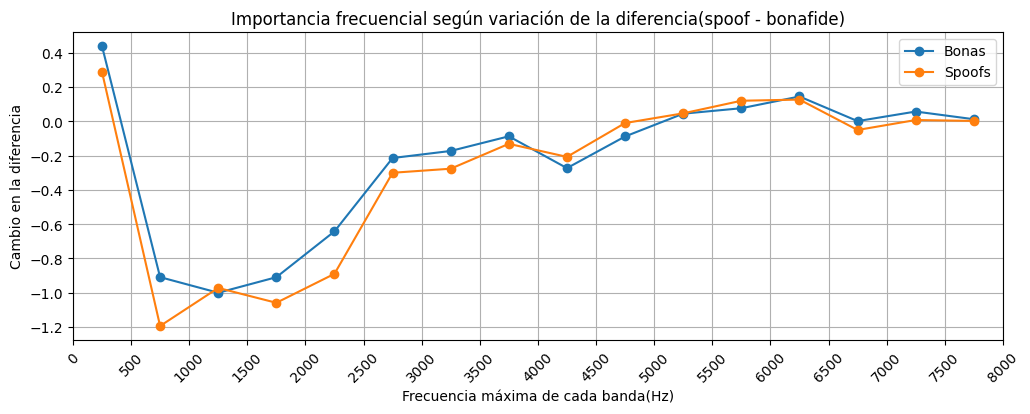

In [ ]:
maps_bonasFreqMargin = np.stack(maps_bonasFreqMargin, axis=0)
maps_spoofsFreqMargin = np.stack(maps_spoofsFreqMargin, axis=0)

maps_bonasFreqLogit = np.stack(maps_bonasFreqLogit, axis=0)
maps_spoofsFreqLogit = np.stack(maps_spoofsFreqLogit, axis=0)

FreqMargin_mean_bonas = maps_bonasFreqMargin.mean(axis=0)
FreqMargin_mean_spoofs = maps_spoofsFreqMargin.mean(axis=0)

FreqLogit_mean_bonas = maps_bonasFreqLogit.mean(axis=0)
FreqLogit_mean_spoofs = maps_spoofsFreqLogit.mean(axis=0)


# Bordes de banda: 0, 500, 1000, ..., 8000  -> 17 valores
edges = np.linspace(0, fmax, n_bands + 1)

# Centros de banda: 250, 750, 1250, ..., 7750 -> 16 valores
centers = 0.5 * (edges[:-1] + edges[1:])

# Labels que quieres mostrar en el eje x
labels = [str(int(x)) for x in edges]

plt.figure(figsize=(12,4))
plt.plot(centers, FreqLogit_mean_bonas, marker="o", label="Bonas")
plt.plot(centers, FreqLogit_mean_spoofs, marker="o", label="Spoofs")
plt.xticks(edges, labels, rotation=45)
plt.xlim(0, fmax)
plt.xlabel("Frecuencia máxima de cada banda(Hz)")
plt.ylabel("Caída del logit al ocultar banda")
plt.title("Importancia frecuencial al ocultar bandas según logit")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(centers, FreqMargin_mean_bonas, marker="o", label="Bonas")
plt.plot(centers, FreqMargin_mean_spoofs, marker="o", label="Spoofs")
plt.xticks(edges, labels, rotation=45)
plt.xlim(0, fmax)
plt.xlabel("Frecuencia máxima de cada banda(Hz)")
plt.ylabel("Cambio en la diferencia")
plt.title("Importancia frecuencial según variación de la diferencia(spoof - bonafide)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
maps_bonas = []
maps_spoofs = []
maps_bonasNor = []
maps_spoofsNor = []

lig = LayerIntegratedGradients(forward_logits, model.conv_time) 
for b in bonas:
    bx, bx4, t = normalize_audio(b)
    lig_attr, _ = use_IG_SC(t,lig, model)
    M_ig = lig_attr[0].detach().cpu().numpy()
    M_vis = np.abs(M_ig)

    LIG_bin, LIG_norm = group_frecs(M_vis)

    maps_bonas.append(LIG_bin)
    maps_bonasNor.append(LIG_norm)
    print(f"Bonas {b}")

for s in spoofs:
    bx, bx4, t = normalize_audio(s)
    lig_attr, _ = use_IG_SC(t,lig, model)
    M_ig = lig_attr[0].detach().cpu().numpy()
    M_vis = np.abs(M_ig)

    LIG_bin, LIG_norm = group_frecs(M_vis)

    maps_spoofs.append(LIG_bin)
    maps_spoofsNor.append(LIG_norm)
    print(f"Spoofs {s}")



Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_20_N.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_10_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_30_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_40_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_40_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_20_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_10_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Ing

In [ ]:
resultados_aasist["maps_bonas"] = maps_bonas
resultados_aasist["maps_spoofs"] = maps_spoofs
resultados_aasist["maps_bonasNor"] = maps_bonasNor
resultados_aasist["maps_spoofsNor"] = maps_spoofsNor

with open("igsc_maps.pkl", "wb") as f:
    pickle.dump(resultados_aasist, f)

In [ ]:
maps_bonas = resultados_aasist["maps_bonas"]
maps_spoofs = resultados_aasist["maps_spoofs"]
maps_bonasNor = resultados_aasist["maps_bonasNor"]
maps_spoofsNor = resultados_aasist["maps_spoofsNor"]

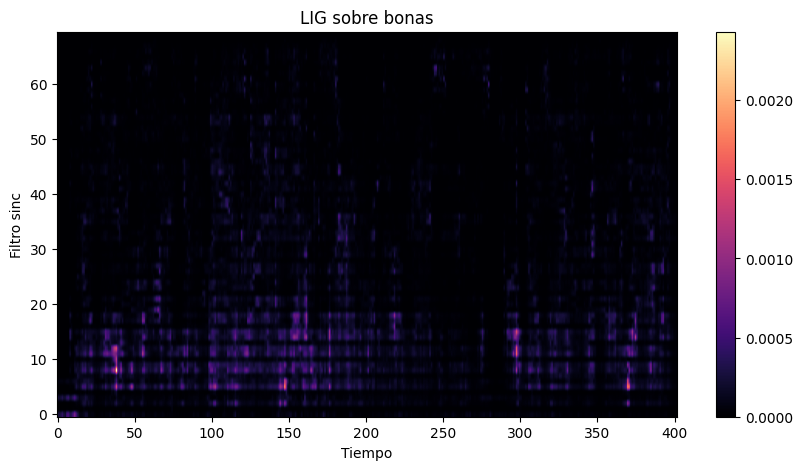

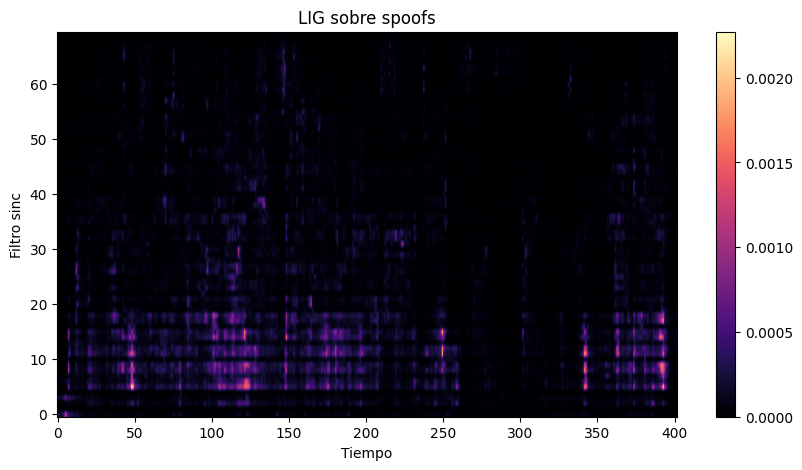

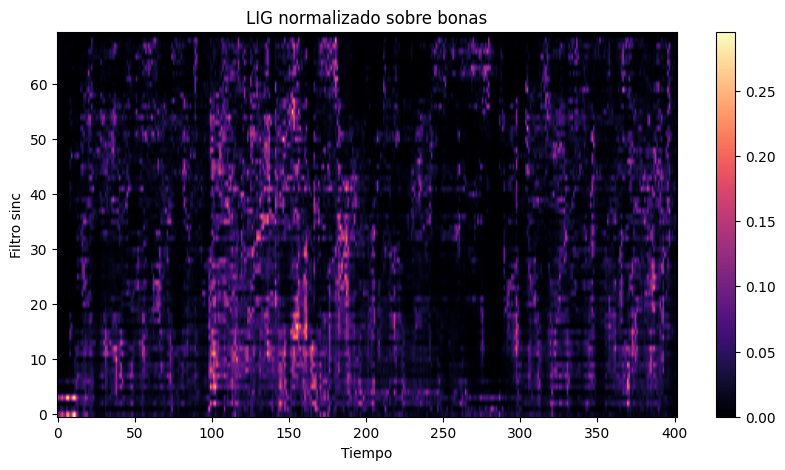

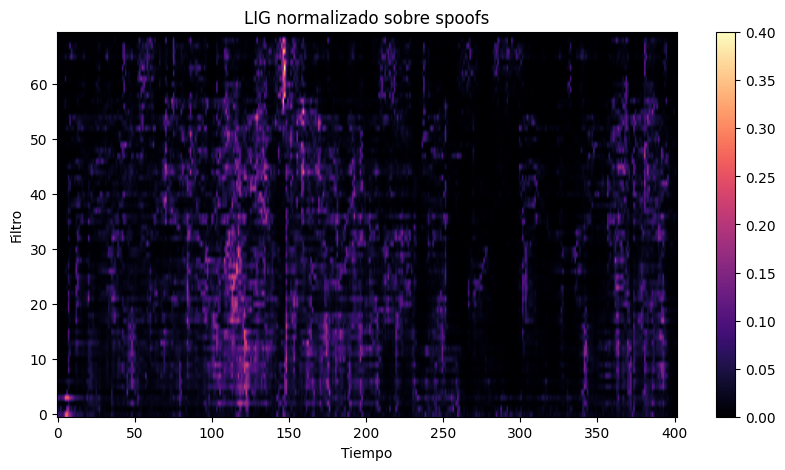

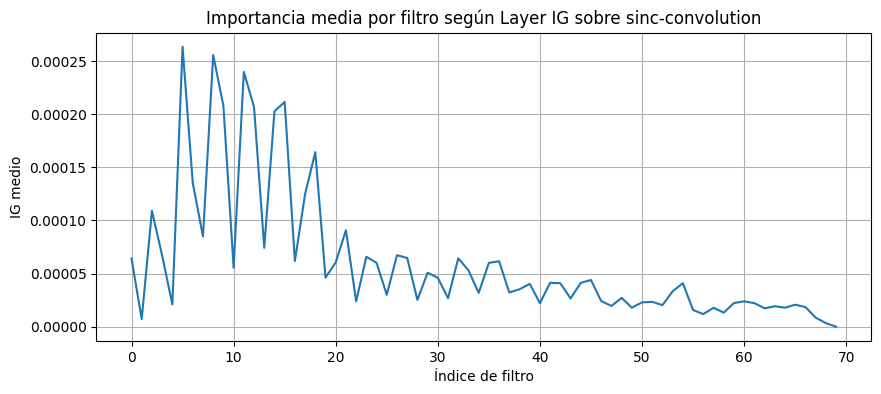

In [ ]:
maps_bonas = np.stack(maps_bonas, axis=0)     # (N_bonas, F, T)
maps_spoofs = np.stack(maps_spoofs, axis=0)   # (N_spoofs, F, T)

IGSC_mean_bonas = maps_bonas.mean(axis=0)   # (F,T)
IGSC_mean_spoofs = maps_spoofs.mean(axis=0) # (F,T)

maps_bonasNor = np.stack(maps_bonasNor, axis=0)     # (N_bonas, F, T)
maps_spoofsNor = np.stack(maps_spoofsNor, axis=0)   # (N_spoofs, F, T)

IGSC_mean_bonasNor = maps_bonasNor.mean(axis=0)   # (F,T)
IGSC_mean_spoofsNor = maps_spoofsNor.mean(axis=0) # (F,T)

plt.figure(figsize=(10,5))
plt.imshow(IGSC_mean_bonas, aspect="auto", origin="lower", cmap="magma")
plt.colorbar()
plt.xlabel("Tiempo")
plt.ylabel("Filtro sinc")
plt.title("LIG sobre bonas")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(IGSC_mean_spoofs, aspect="auto", origin="lower", cmap="magma")
plt.colorbar()
plt.xlabel("Tiempo")
plt.ylabel("Filtro sinc")
plt.title("LIG sobre spoofs")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(IGSC_mean_bonasNor, aspect="auto", origin="lower", cmap="magma")
plt.colorbar()
plt.xlabel("Tiempo")
plt.ylabel("Filtro sinc")
plt.title("LIG normalizado sobre bonas")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(IGSC_mean_spoofsNor,aspect="auto",origin="lower",cmap="magma")
plt.colorbar()
plt.xlabel("Tiempo")
plt.ylabel("Filtro")
plt.title("LIG normalizado sobre spoofs")
plt.show()

ig_filt = IGSC_mean_bonas.mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(ig_filt)), ig_filt)
plt.xlabel("Índice de filtro")
plt.ylabel("IG medio")
plt.title("Importancia media por filtro según Layer IG sobre sinc-convolution")
plt.grid(True)
plt.show()

In [ ]:
maps_bonasWav = []
maps_spoofsWav = []
maps_bonasWavNor = []
maps_spoofsWavNor = []

ig = IntegratedGradients(forward_logits)

for b in bonas:
    bx, bx4, t = normalize_audio(b)
    attrs, _ = use_IG_Wav(t, ig, model)

    attr_audio = attrs[0].detach().cpu().numpy()
    attr_abs = np.abs(attr_audio)

    num_bloques = len(attr_abs) // bin_len
    attr_bin = attr_abs[:num_bloques * bin_len].reshape(num_bloques, bin_len).mean(axis=1)
    attr_norm = attr_bin / (attr_bin.max() + 1e-8)

    maps_bonasWav.append(attr_bin)
    maps_bonasWavNor.append(attr_norm)
    print(f"Bonas {b}")

for s in spoofs:
    bx, bx4, t = normalize_audio(s)
    attrs, _ = use_IG_Wav(t, ig, model)

    attr_audio = attrs[0].detach().cpu().numpy()
    attr_abs = np.abs(attr_audio)

    num_bloques = len(attr_abs) // bin_len
    attr_bin = attr_abs[:num_bloques * bin_len].reshape(num_bloques, bin_len).mean(axis=1)
    attr_norm = attr_bin / (attr_bin.max() + 1e-8)

    maps_spoofsWav.append(attr_bin)
    maps_spoofsWavNor.append(attr_norm)
    print(f"Spoofs {s}")

Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_30_N.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_20_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_10_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_40_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_30_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_20_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Ing

In [ ]:
resultados_aasist["maps_bonasWav"] = maps_bonasWav
resultados_aasist["maps_spoofsWav"] = maps_spoofsWav
resultados_aasist["maps_bonasWavNor"] = maps_bonasWavNor
resultados_aasist["maps_spoofsWavNor"] = maps_spoofsWavNor

with open("igsc_maps.pkl", "wb") as f:
    pickle.dump(resultados_aasist, f)

In [ ]:
maps_bonasWav = resultados_aasist["maps_bonasWav"]
maps_spoofsWav = resultados_aasist["maps_spoofsWav"]
maps_bonasWavNor = resultados_aasist["maps_bonasWavNor"]
maps_spoofsWavNor = resultados_aasist["maps_spoofsWavNor"]

maps_bonasWav = np.stack(maps_bonasWav, axis=0)      # (N_bonas, T)
maps_spoofsWav = np.stack(maps_spoofsWav, axis=0)    # (N_spoofs, T)

IGWav_mean_bonas = maps_bonasWav.mean(axis=0)
IGWav_mean_spoofs = maps_spoofsWav.mean(axis=0)

IGWav_std_bonas = maps_bonasWav.std(axis=0)
IGWav_std_spoofs = maps_spoofsWav.std(axis=0)

diff_wav = IGWav_mean_bonas - IGWav_mean_spoofs

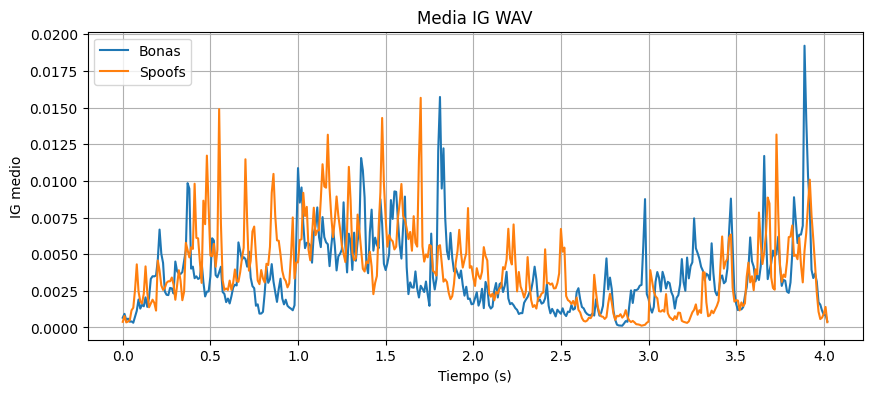

In [ ]:
x_sec = np.arange(len(IGWav_mean_bonas)) * bin_ms / 1000.0

plt.figure(figsize=(10, 4))
plt.plot(x_sec, IGWav_mean_bonas, label="Bonas")
plt.plot(x_sec, IGWav_mean_spoofs, label="Spoofs")

plt.xlabel("Tiempo(s)")
plt.ylabel("IG medio")
plt.title("Media IG WAV")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
rise_sal = []
rise_salM = []
for b in bonas:
    bx, bx4, t = normalize_audio(b)
    sal, salM = rise(x=bx4, t = t, model = model)
    rise_sal.append(sal)
    rise_salM.append(salM)
    print(f"Bonas {b}")

rise_sal = np.stack(rise_sal, axis=0)   # forma: (n_audios, T)
rise_salM = np.stack(rise_salM, axis=0)   

rise_salG = []
rise_salMG = []
for s in spoofs:
    bx, bx4, t = normalize_audio(s)
    sal, salM = rise(x=bx4, t = t, model = model)
    rise_salG.append(sal)
    rise_salMG.append(salM)
    print(f"Spoofs {s}")


rise_salG = np.stack(rise_salG, axis=0) 
rise_salMG = np.stack(rise_salMG, axis=0)  

Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_10_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_40_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_50_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_30_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Español/E_20_N.wav
Bonas C:\TFG\Datasets\Propio\Natural\Inglés/I_50_N.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_30_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_10_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_40_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_50_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_20_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Inglés/I_20_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Español/E_10_G.wav
Spoofs C:\TFG\Datasets\Propio\Generado\Espa

In [ ]:
resultados_aasist["rise_sal"] = rise_sal
resultados_aasist["rise_salM"] = rise_salM
resultados_aasist["rise_salG"] = rise_salG
resultados_aasist["rise_salMG"] = rise_salMG

with open("igsc_maps.pkl", "wb") as f:
    pickle.dump(resultados_aasist, f)

In [ ]:
rise_sal = resultados_aasist["rise_sal"] 
rise_salM = resultados_aasist["rise_sal"] 
rise_salG = resultados_aasist["rise_salG"]
rise_salMG = resultados_aasist["rise_salMG"]

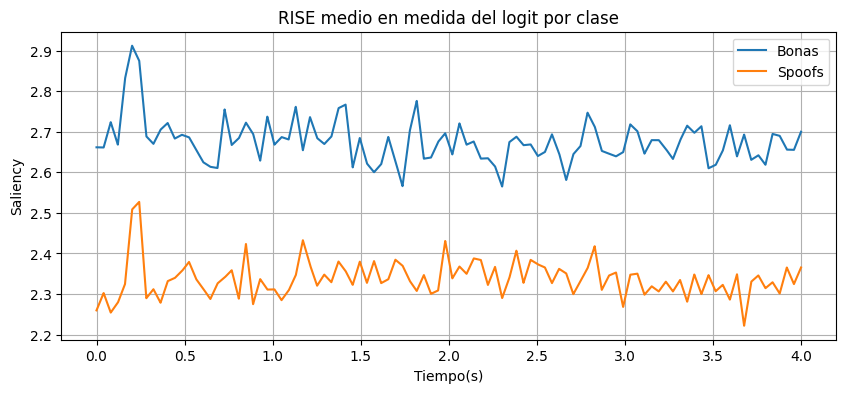

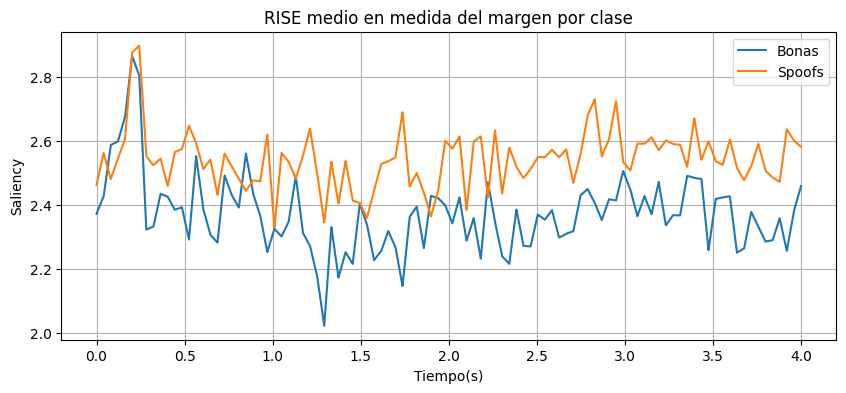

In [ ]:
rise_mean_bona = rise_sal.mean(axis=0)       # forma: (T,)
rise_mean_spoof = rise_salG.mean(axis=0)       # forma: (T,)
x_sec = np.linspace(0, 4.0, len(rise_mean_bona))
plt.figure(figsize=(10,4))
plt.plot(x_sec, rise_mean_bona, label="Bonas")
plt.plot(x_sec, rise_mean_spoof, label="Spoofs")
plt.xlabel("Tiempo(s)")
plt.ylabel("Saliency")
plt.title("RISE medio en medida del logit por clase")
plt.grid(True)
plt.legend()
plt.show()

rise_mean_bonaM = rise_salM.mean(axis=0)       # forma: (T,)
rise_mean_spoofM = rise_salMG.mean(axis=0)       # forma: (T,)
x_sec = np.linspace(0, 4.0, len(rise_mean_bonaM))
plt.figure(figsize=(10,4))
plt.plot(x_sec, rise_mean_bonaM, label="Bonas")
plt.plot(x_sec, rise_mean_spoofM, label="Spoofs")
plt.xlabel("Tiempo(s)")
plt.ylabel("Saliency")
plt.title("RISE medio en medida del margen por clase")
plt.grid(True)
plt.legend()
plt.show()

## SHAP
Como shap no se puede aplicar sobre aasist porque recibe una onda de audio cruda en vez de caracteristicas y es un modelo muy costoso de llamar muchas veces, hemos intentado usar dos modelo surrogate que imite la salida de aasist

# 1. IMPORTS

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor, XGBClassifier
import shap
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, balanced_accuracy_score, roc_auc_score

# 2.RUTAS

In [ ]:
FEATURES_CSV = "features.csv" 
AASIST_CSV   = "aasist_results.csv"    
OUT_CSV      = "features_with_aasist.csv"

AASIST_SCORE_COL = "prob1_mean"  #nombre de la columna del aasist.csv

FILENAME_NORMALIZATION = "basename" #para el punto 4

# 3. Carga de csvs

In [ ]:
feats = pd.read_csv(FEATURES_CSV)
aas  = pd.read_csv(AASIST_CSV)

# 4. Comparación de rutas y validación de la columna score

Normaliza las rutas de ambos csvs para que no haya errores por rutas distintas aunque se refieran al mismo audio y además luego facilita el nombrar archivos para la separación manual de los audios en train y test.

In [ ]:
def normalize_fn(x: str) -> str:
    x = str(x)
    if FILENAME_NORMALIZATION == "basename": #solo el nombre del archivo
        return os.path.basename(x)
    if FILENAME_NORMALIZATION == "normpath": #toda la ruta
        return os.path.normpath(x)
    return x 

feats["filename"] = feats["filename"].apply(normalize_fn)
aas["filename"]  = aas["path"].apply(normalize_fn)

#asegura que la columna de score existe
if AASIST_SCORE_COL not in aas.columns:
    raise ValueError(
        f"No encuentro la columna '{AASIST_SCORE_COL}' en {AASIST_CSV}. "
    )

# 5. Merge

El resultado es el csv de caracteristicas más la fila de score de aasist. Además, inner descarta archivos que no esten en ambos por si acaso.

In [ ]:
df = feats.merge(aas[["filename", AASIST_SCORE_COL]], on="filename", how="inner")

#alguna comprobación para el merge
print("Filas features:", len(feats))
print("Filas aasist:", len(aas))
print("Filas merge:", len(df))

#el logit sirve para que los valores no estén cerrado entre [0,1] y crezca de manera más lineal
p = df[AASIST_SCORE_COL].clip(1e-6, 1-1e-6)
df["aasist_logit_bona"] = np.log(p/(1-p))
AASIST_SCORE_COL = "aasist_logit_bona"

#reordena para poner prob de bonafide al principio del csv
cols = df.columns.tolist()
new_order = ["filename", AASIST_SCORE_COL] + [c for c in cols if c not in ("filename", AASIST_SCORE_COL)]
df = df[new_order]

df.to_csv(OUT_CSV, index=False)
print(f"Guardado: {OUT_CSV}")

Filas features: 200
Filas aasist: 200
Filas merge: 200
Guardado: features_with_aasist.csv


# 6. Construir X e y(columna a imitar) y arreglo de formatos para evitar errores 

In [ ]:
#sirve para quitar las columnas que no son features y no se quieren usar para entrenar el surrogate
DROP_COLS = ["filename", AASIST_SCORE_COL, "prob1_mean", "label"] 

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
#y = df[AASIST_SCORE_COL].astype(float).values

#todo lo que no sea numérico lo convierte a NaN
X = X.apply(pd.to_numeric, errors="coerce")

y = (df["prob1_mean"].astype(float) >= 0.5).astype(int).values

# 7. División del dataset



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

X_test.to_csv("X_test.csv", index=False) #guardamos los audios de X_test

# 8. Entrenar el surrogate y fidelidad con aasist

R2 sirve para ver como de fiel es el surrogate, como vemos al entrenar si que tiene un valor cercano a 1 lo cual es aceptable pero en test tiene un valor que no refleja el modelo de aasist

In [ ]:
clas = XGBClassifier(
    n_estimators=100, #número de árboles, subirlo puede llevar a sobreajuste
    max_depth=3, #prof máxima de cada árbol
    learning_rate=0.05, #le peso de cada árbol nuevo
    subsample=0.7, #% de audios que usa cada árbol
    colsample_bytree=0.7, #% de features que usa cada árbol
    reg_lambda=10.0, #penaliza pesos grandes
    reg_alpha=1.0, #penaliza pesos pequeños
    min_child_weight=5, #controla la creación de nodos nuevos
    gamma=0.5, #coste mínimo para hacer un split
    random_state=0 #aleatoriedad 
)

clas.fit(X_train, y_train)

y_train_pred = clas.predict(X_train)
y_test_pred  = clas.predict(X_test)

print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

clas.save_model("xgb_clas.json") #para guardar el modelo y no tener que volver a entrenar cada vez

[[18  0]
 [ 3 19]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        18
           1       1.00      0.86      0.93        22

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.94      0.93      0.93        40



In [ ]:
sur = XGBRegressor(
    n_estimators=100, #número de árboles, subirlo puede llevar a sobreajuste
    max_depth=3, #prof máxima de cada árbol
    learning_rate=0.05, #le peso de cada árbol nuevo
    subsample=0.7, #% de audios que usa cada árbol
    colsample_bytree=0.7, #% de features que usa cada árbol
    reg_lambda=10.0, #penaliza pesos grandes
    reg_alpha=1.0, #penaliza pesos pequeños
    min_child_weight=5, #controla la creación de nodos nuevos
    gamma=0.5, #coste mínimo para hacer un split
    random_state=0 #aleatoriedad 
)
sur.fit(X_train, y_train)

train_pred = sur.predict(X_train)
test_pred  = sur.predict(X_test)
print("R2 train:", r2_score(y_train, train_pred))
print("R2 test :", r2_score(y_test, test_pred))

sur.save_model("xgb_sur.json")

R2 train: 0.8274016380310059
R2 test : 0.6628223657608032


c:\Users\gerbq\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


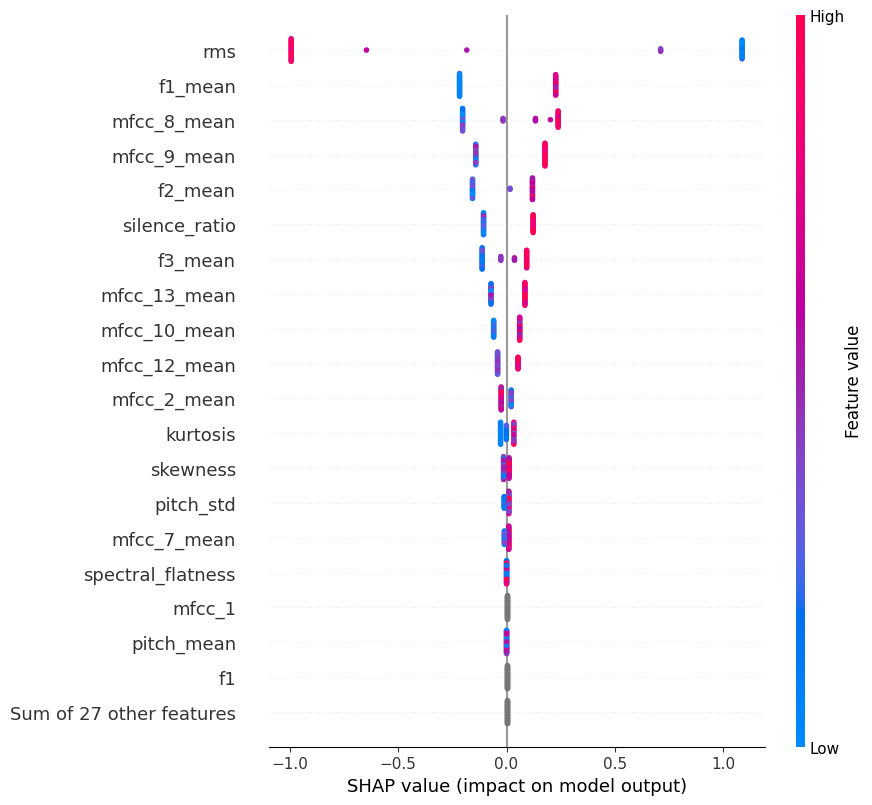

<Figure size 640x480 with 0 Axes>

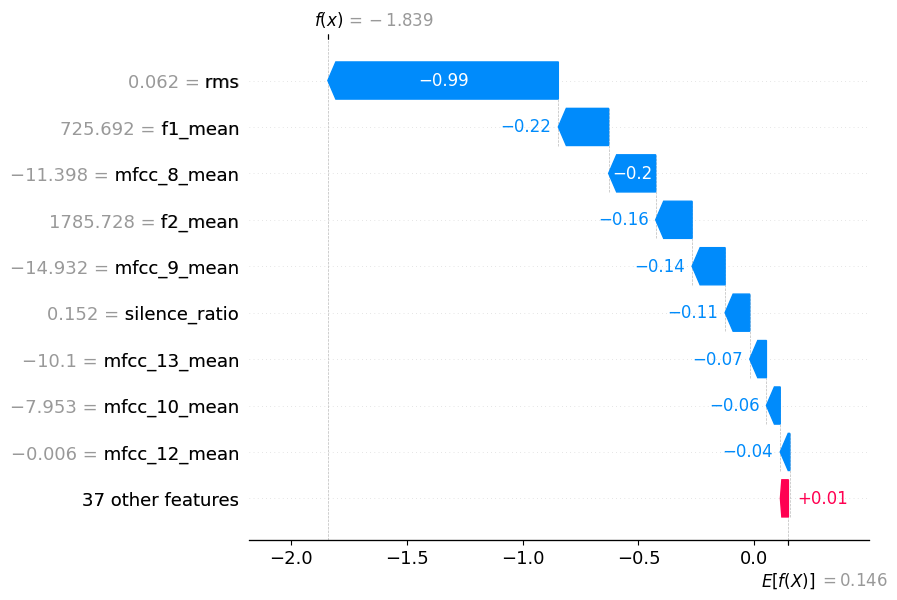

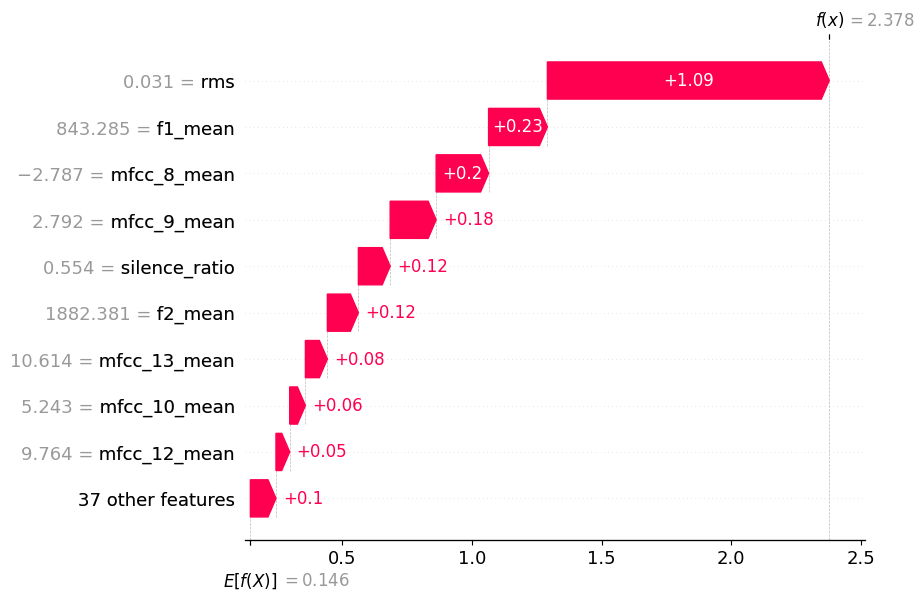

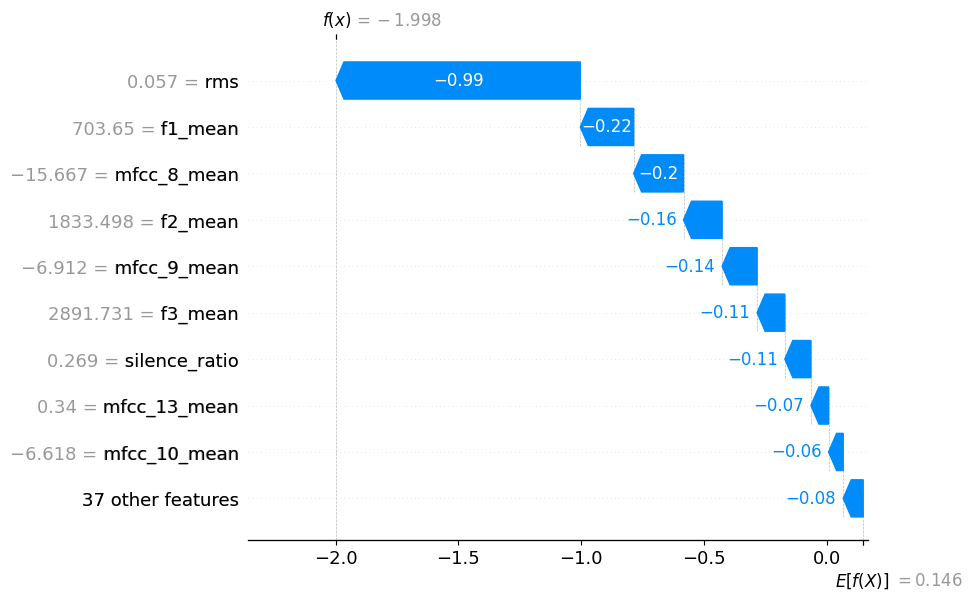

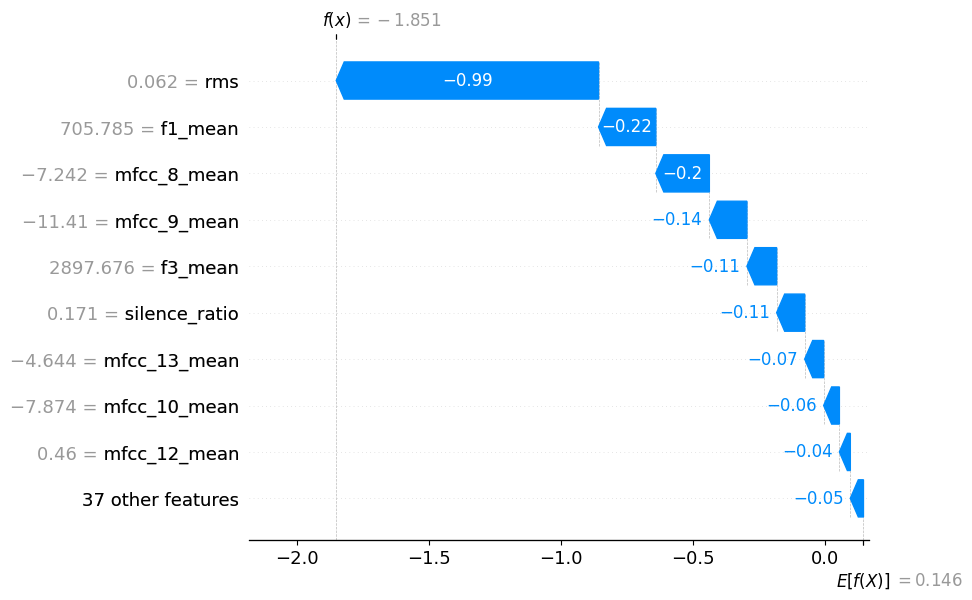

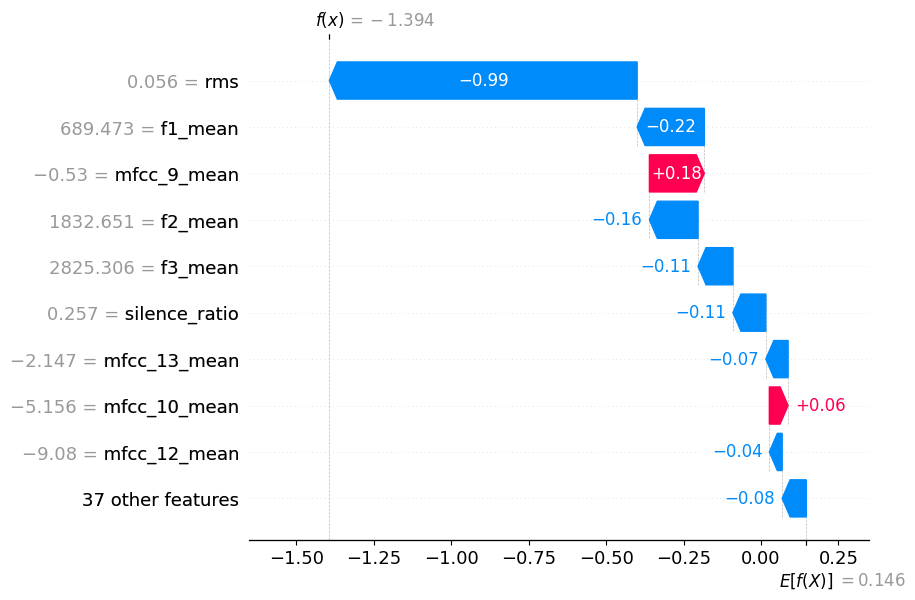

In [ ]:
explainer = shap.TreeExplainer(clas)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=20)
plt.tight_layout()
plt.show()

for i in range(5):
    shap.plots.waterfall(shap_values[i])

c:\Users\gerbq\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


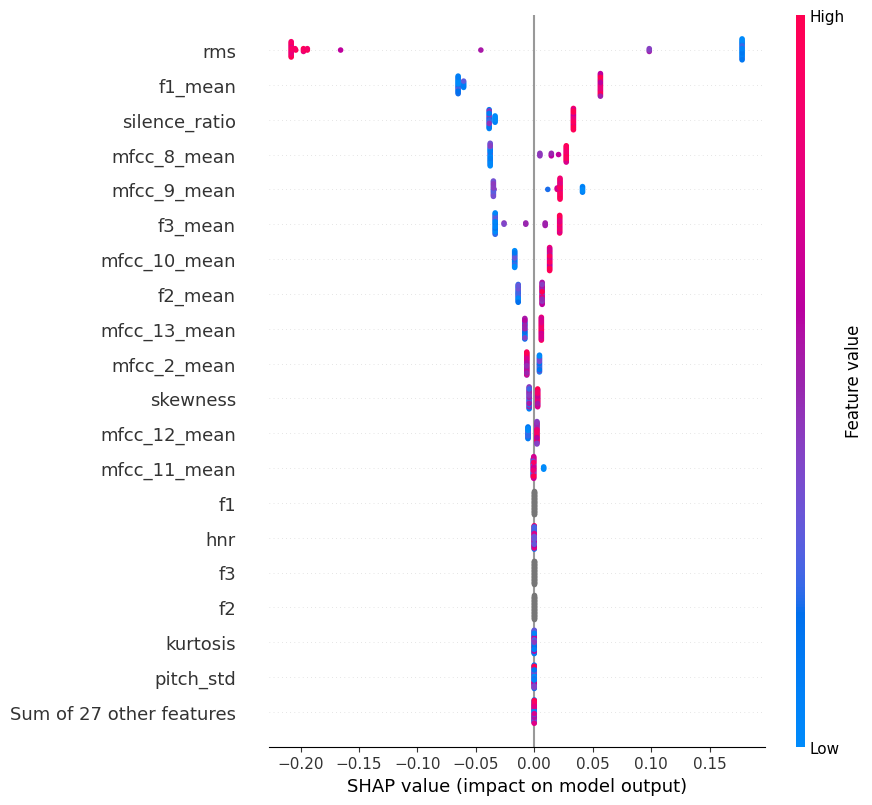

<Figure size 640x480 with 0 Axes>

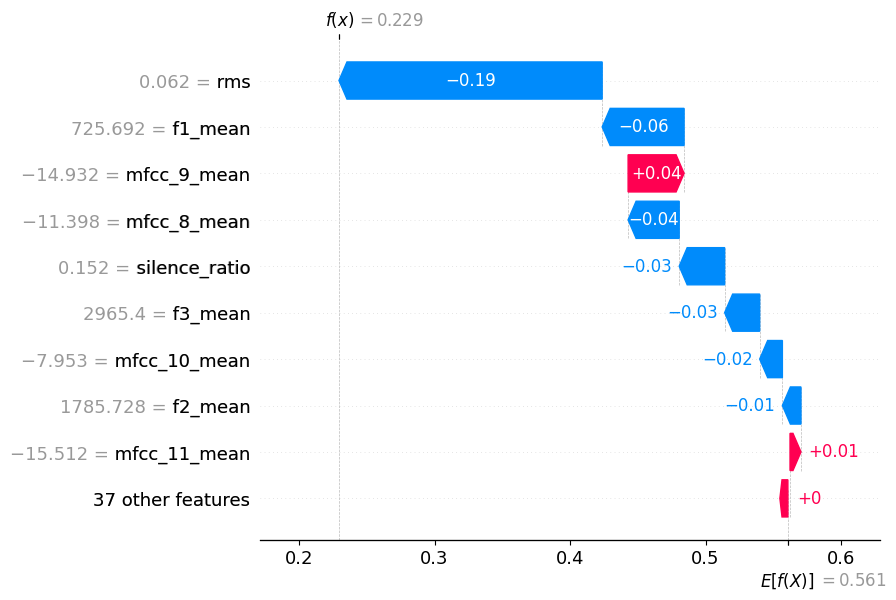

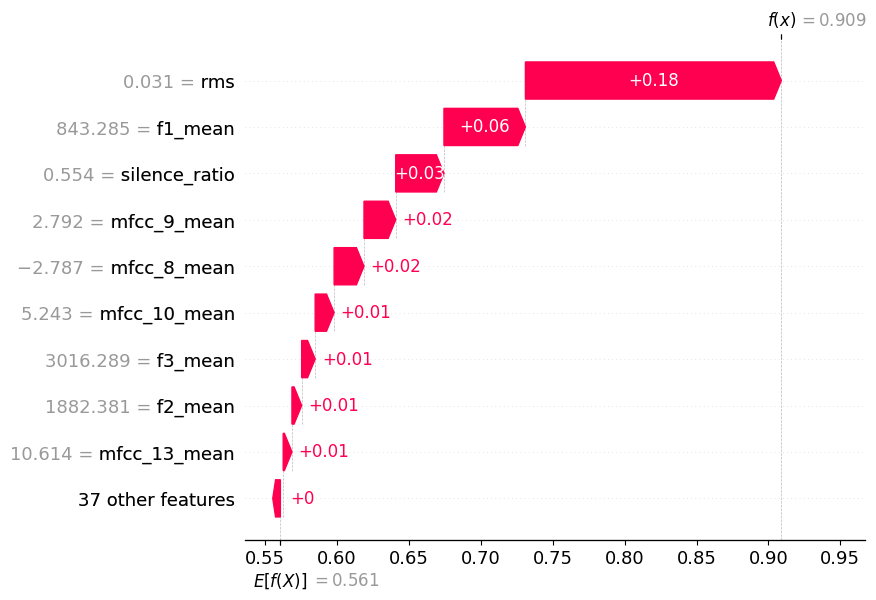

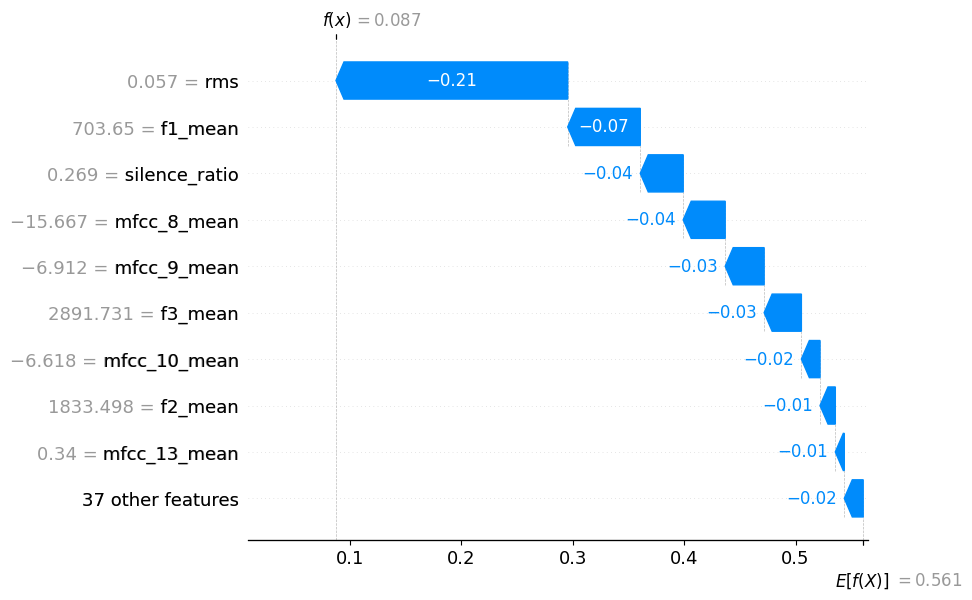

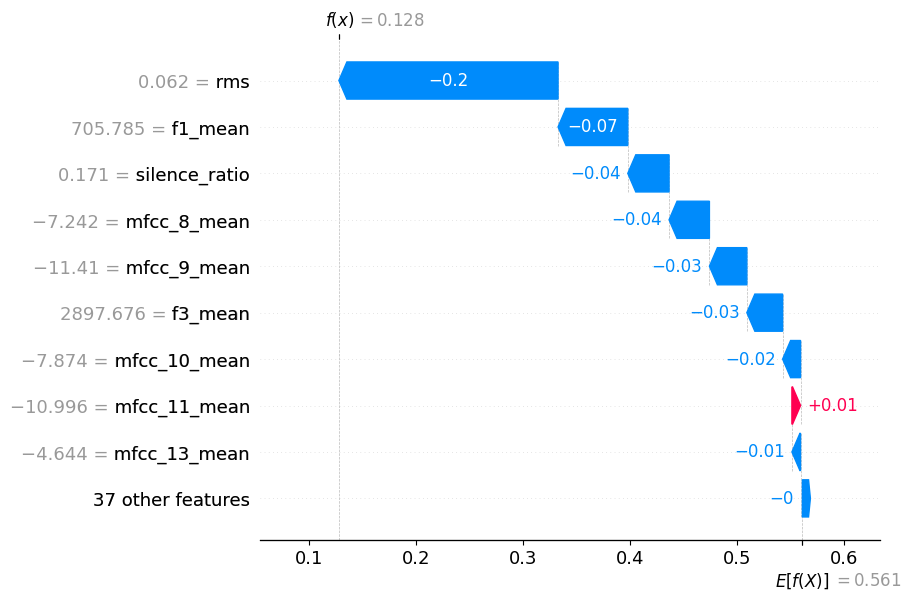

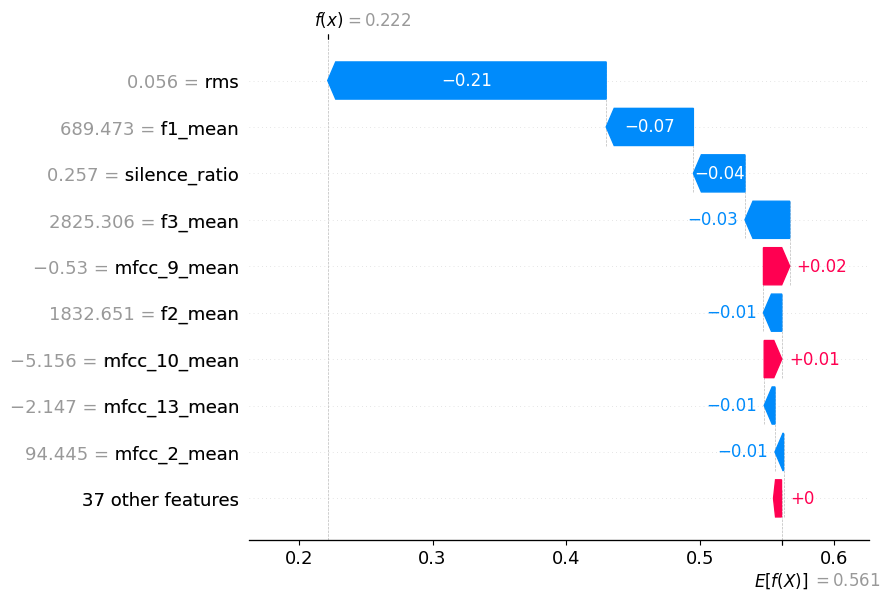

In [ ]:
explainer = shap.Explainer(sur, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=20)
plt.tight_layout()
plt.show()

for i in range(5):
    shap.plots.waterfall(shap_values[i])